In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [14]:
df = sns.load_dataset("titanic")

features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

#handle missing data
imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])

imp_freq = SimpleImputer(strategy='most_frequent')
df[["embarked"]] = imp_freq.fit_transform(df[["embarked"]])

#encode

le = LabelEncoder()
df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

X = df[features]
y = df["survived"]

# train test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3 , random_state= 42)


In [25]:
# decision tree

model = DecisionTreeClassifier( max_depth= 4)
model.fit(X_train , y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(f'Trainning Score : {accuracy_score(y_train , y_pred_train) * 100:2f}%')
print(f'Testing Score : {accuracy_score(y_test , y_pred_test) * 100:2f}%')

Trainning Score : 84.751204%
Testing Score : 82.462687%


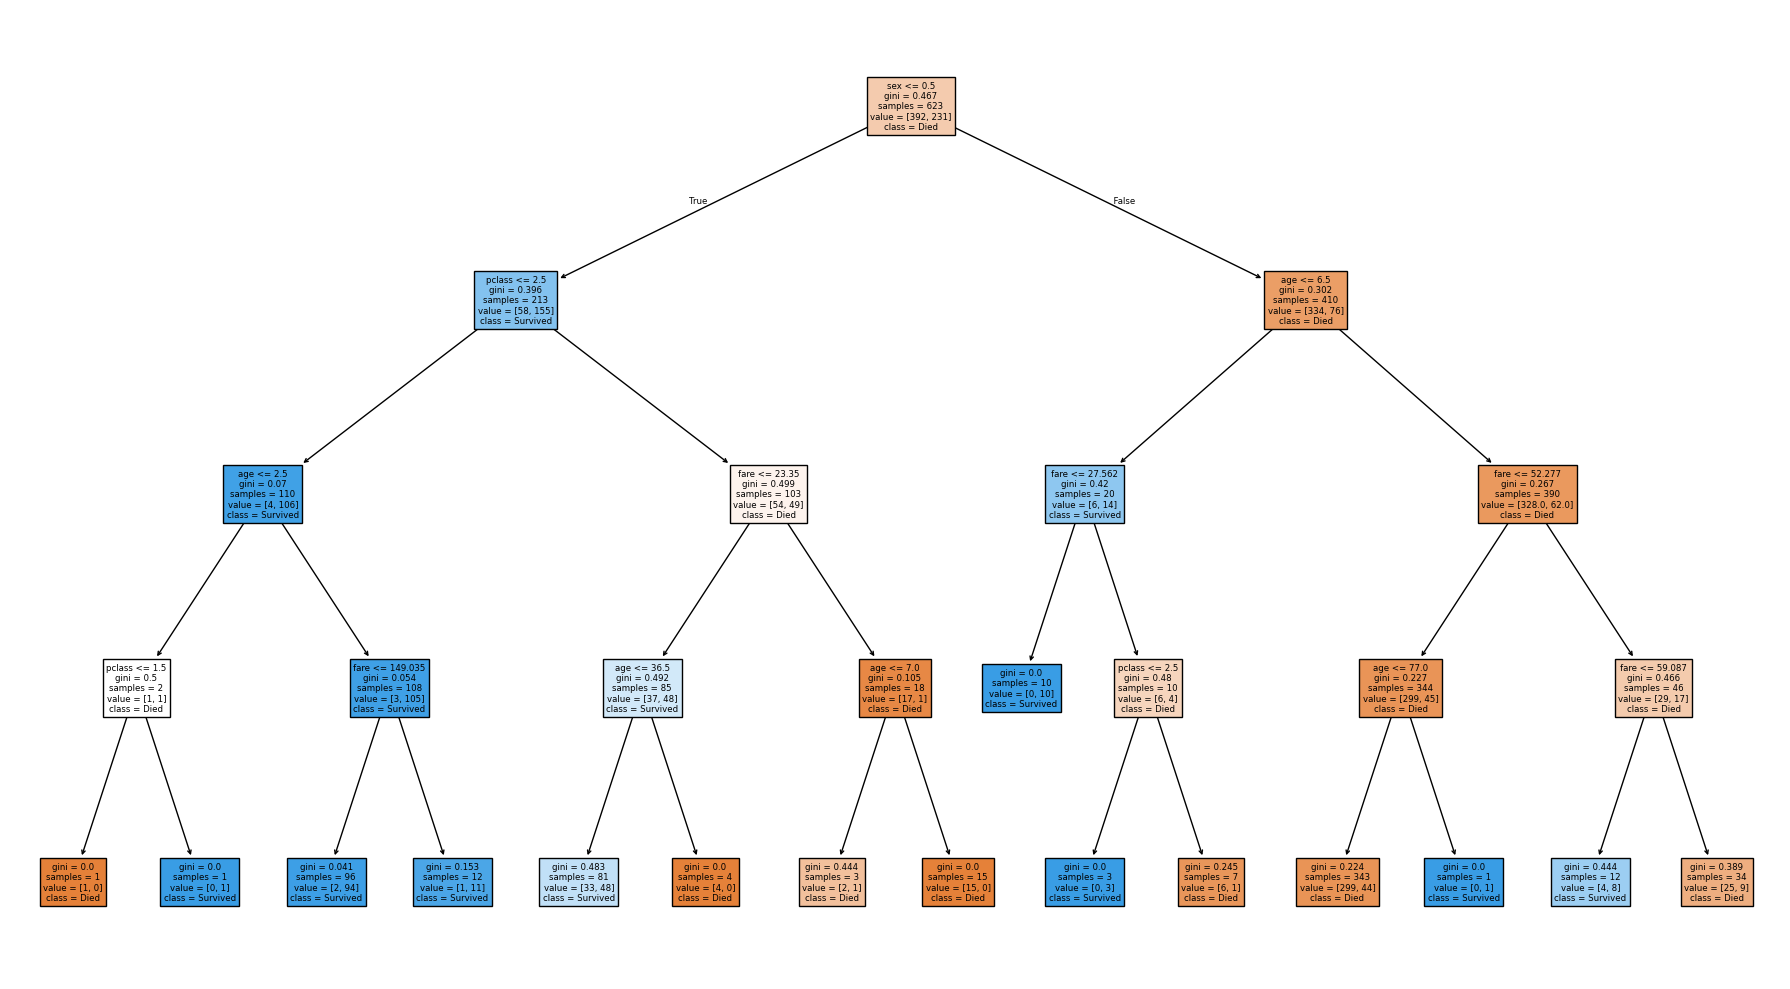

In [21]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names= X.columns,
    class_names= ["Died", "Survived"],
    filled= True
)

plt.tight_layout()

In [23]:
# random forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators= 301,
    oob_score= True,
    max_depth= 4
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f'OOB Score : {rf_model.oob_score_ * 100:.2f}%')
print(f'accuracy Score : {accuracy_score(y_test , y_pred) * 100:.2f}%')


OOB Score : 82.66%
accuracy Score : 82.46%


In [ ]:
# Bagging Classifier

from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators= 201,
    oob_score= True,
)

bagging.fit(X_train , y_train)
y_pred = bagging.predict(X_test)

print(f'OOB Score : {bagging.oob_score_ * 100:.2f}%')
print(f'accuracy Score : {accuracy_score(y_test , y_pred) * 100:.2f}%')


OOB Score : 80.42%
accuracy Score : 77.61%


In [28]:
# Bagging Classifier

from sklearn.linear_model import LogisticRegression 

base_model = LogisticRegression(max_iter= 1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators= 201,
    oob_score= True,
)

bagging.fit(X_train , y_train)
y_pred = bagging.predict(X_test)

print(f'OOB Score : {bagging.oob_score_ * 100:.2f}%')
print(f'accuracy Score : {accuracy_score(y_test , y_pred) * 100:.2f}%')

OOB Score : 78.65%
accuracy Score : 79.48%


In [31]:
#decision tree regressor
from sklearn.datasets import load_diabetes
df = load_diabetes(as_frame= True).frame

X = df.drop("target", axis= 1)
y = df["target"]

X_train , X_test, y_train, y_test = train_test_split(X, y , test_size=0.3 , random_state= 42)



In [32]:
from sklearn.tree import DecisionTreeRegressor

moedl = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(f'Accuracy Train : {accuracy_score(y_train , y_pred_train) * 100:.2f}%')
print(f'Accuracy of Test : {accuracy_score(y_test , y_pred_test) * 100:.2f}%')



Accuracy Train : 9.71%
Accuracy of Test : 0.75%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/tree/_classes.py:297: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  check_classification_targets(y)


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error , r2_score


rf_model_regressor = RandomForestRegressor(
    n_estimators= 301,
    oob_score= True,
    max_depth= 4
)

rf_model_regressor.fit(X_train, y_train)

y_pred = rf_model_regressor.predict(X_test)

print(f'OOB Score : {rf_model_regressor.oob_score_ * 100:.2f}%')
print(f'MSE Score : {mean_squared_error(y_test , y_pred) * 100:.2f}%')
print(f'R2 Score : {r2_score(y_test , y_pred) * 100:.2f}%')


OOB Score : 44.81%
MSE Score : 276183.19%
R2 Score : 48.84%
